## Importing Libraries and Loading Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
sns.set_style('white')

In [3]:
deaths = pd.read_csv('../data/raw/number-of-deaths.csv')
pop = pd.read_csv('../data/raw/population.csv')
gdp = pd.read_csv('../data/raw/gdp-per-capita-maddison-project-database.csv')
life_exp = pd.read_csv('../data/raw/life-expectancy-unwpp.csv')
income = pd.read_csv('../data/raw/daily-median-income.csv')

In [ ]:
# Renaming key columns in each dataset
deaths = deaths.rename(columns={'Number of deaths, total': 'deaths'})
pop = pop.rename(columns={'Population': 'population'})
gdp = gdp.rename(columns={'GDP': 'gdp_per_capita'})
life_exp = life_exp.rename(columns={'Life Expectancy':'life_exp'})

In [5]:
for df in (deaths, pop, gdp, life_exp, income):
    df.columns = df.columns.str.lower()

In [6]:
# Merging datasets into one df
df = deaths.merge(pop, on = ['entity', 'year', 'code'], how = 'inner')\
    .merge(gdp, on = ['entity', 'year', 'code'], how = 'inner')\
    .merge(life_exp, on = ['entity', 'year', 'code'], how = 'inner')

## Data Validation
- The dataset contans 11,545 rows, covering 166 countries and 73 years (1950 - 2022).
- No missing values or duplicated rows

In [7]:
df.head()

,entity,code,year,deaths,population,gdp_per_capita,life_exp
0,Afghanistan,AFG,1950,290972,7776180,1156.0,28.156
1,Afghanistan,AFG,1951,288752,7879343,1170.0,28.584
2,Afghanistan,AFG,1952,288059,7987784,1189.0,29.014
3,Afghanistan,AFG,1953,287712,8096703,1240.0,29.452
4,Afghanistan,AFG,1954,289189,8207954,1245.0,29.698


In [8]:
df.describe()

,year,deaths,population,gdp_per_capita,life_exp
count,11545.000000,1.154500e+04,1.154500e+04,11545.000000,11545.000000
mean,1986.981897,3.869352e+05,3.950924e+07,10431.922325,62.730742
std,20.942012,2.287774e+06,2.620185e+08,13350.938575,12.542164
min,1950.000000,4.020000e+02,2.430400e+04,377.580080,11.295000
25%,1969.000000,2.145100e+04,2.439219e+06,1949.000000,53.422000
50%,1988.000000,7.840600e+04,6.763902e+06,5367.795000,65.609000
75%,2005.000000,2.018480e+05,2.055812e+07,13238.000000,72.477000
max,2022.000000,6.972810e+07,8.021407e+09,160051.230000,85.263000


In [9]:
# Calculating mortality_rate
df['mortality_rate'] = df['deaths']/df['population']
df['mortality_per_1000'] = df['mortality_rate'] * 1000

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

entity                0
code                  0
year                  0
deaths                0
population            0
gdp_per_capita        0
life_exp              0
mortality_rate        0
mortality_per_1000    0
dtype: int64

In [12]:
df['year'].max() - df['year'].min()

np.int64(72)

In [13]:
df['entity'].nunique()

166

## EDA

### Univariate analysis
- **Year:** The distribution of the `year` variable is approximately uniform, with observations spread fairly evenly from 1950 to 2022. There is no evidence of outliers, and the negative kurtosis indicates a flatter-than-normal distribution, which is expected for a uniformly distributed time variable. This suggests that the dataset has consistent temporal coverage across years, reducing the risk of temporal bias in subsequent analyses. As a result, trends observed in time series analysis are less likely to be driven by uneven sampling across specific periods. 

- **Mortality Rate:** The distribution of `mortality_per_1000` is highly right-skewed. This indicates that while most country-year observations cluster at lower mortality levels, a small subset exhibits substantially higher mortality. These outliers likely correspond to specific periods of crisis or systemic breakdown (such as conflict, famine, or epidemics). 

- **GDP per Capita:** The distribution of `gdp_per_capita` is strongly right-skewed, driven by a small number of very high-income country-year observations. This is expected given the global structure of income, where high-income economies (e.g., United States, Switzerland, Norway) are relatively few compared to the large number of low- and middle-income countries.  

- **Life Expectancy:** `life_exp` is slightly left0-skewed, but the distribution is close to symmetric, and with only a small number of outliers. The small number of outliers suggests that extreme deviations are rare and likely tied to specific historical or crisis-driven contexts rather than widespread noise.

In [14]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - IQR * 1.5
    upper = Q3 + IQR * 1.5

    mask = (series < lower)|(series > upper)
    return series[mask]

def univariate_analysis(df, col):
    data = df[col].dropna()

    print(f"\n--- Summary stats for {col} ---")

    # Summary stats
    print(f'Mean: {data.mean():.2f}')
    print(f'Median: {data.median():.2f}')
    print(f'Std Dev: {data.std():.2f}')
    print(f'Skewness: {data.skew():.2f}')
    print(f'Kurtosis: {data.kurtosis():.2f}')
 
    # Outlier detection
    outliers = detect_outliers(data)
    print(f"Outliers: {len(outliers)} ({100 * len(outliers)/len(data):.2f}%)")

    # Visualization
    fig, axes = plt.subplots(1,2, figsize = (10,5))
    fig.suptitle(f'Distribution of {col}', fontsize = 12)

    # Histogram
    sns.histplot(x = data, kde = True, edgecolor = 'black', alpha = 0.7, ax = axes[0])
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Histogram')
    axes[0].axvline(data.mean(), color = 'red', label = 'Mean', linewidth = 1)
    axes[0].axvline(data.median(), color = 'green', linestyle = '--', label = 'Median', linewidth = 1)
    axes[0].legend()
    
    # Box plot
    sns.boxplot(y = data, ax = axes[1])
    axes[1].set_ylabel(col)
    axes[1].set_title('Box plot')

    plt.tight_layout()
    plt.show()


--- Summary stats for year ---
Mean: 1986.98
Median: 1988.00
Std Dev: 20.94
Skewness: -0.06
Kurtosis: -1.18
Outliers: 0 (0.00%)


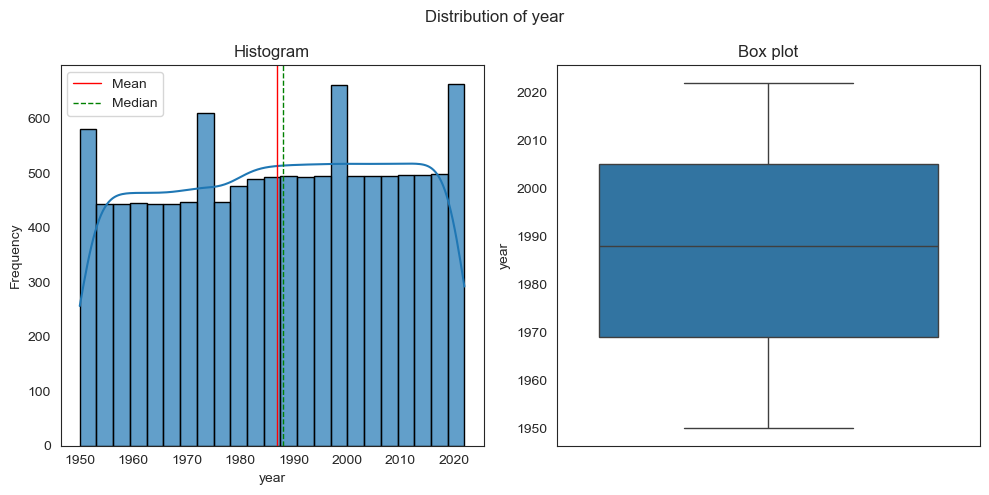


--- Summary stats for mortality_per_1000 ---
Mean: 11.72
Median: 9.87
Std Dev: 6.54
Skewness: 2.64
Kurtosis: 28.16
Outliers: 602 (5.21%)


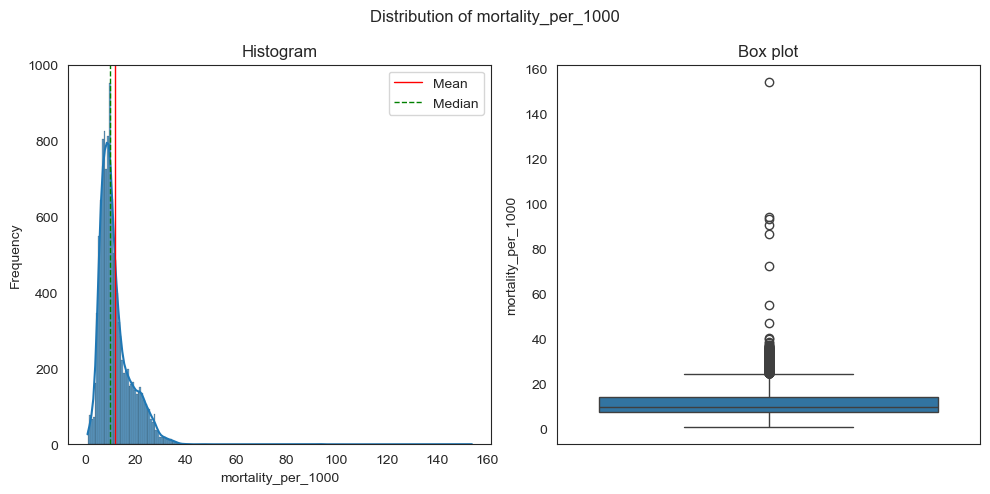


--- Summary stats for gdp_per_capita ---
Mean: 10431.92
Median: 5367.80
Std Dev: 13350.94
Skewness: 3.16
Kurtosis: 18.41
Outliers: 970 (8.40%)


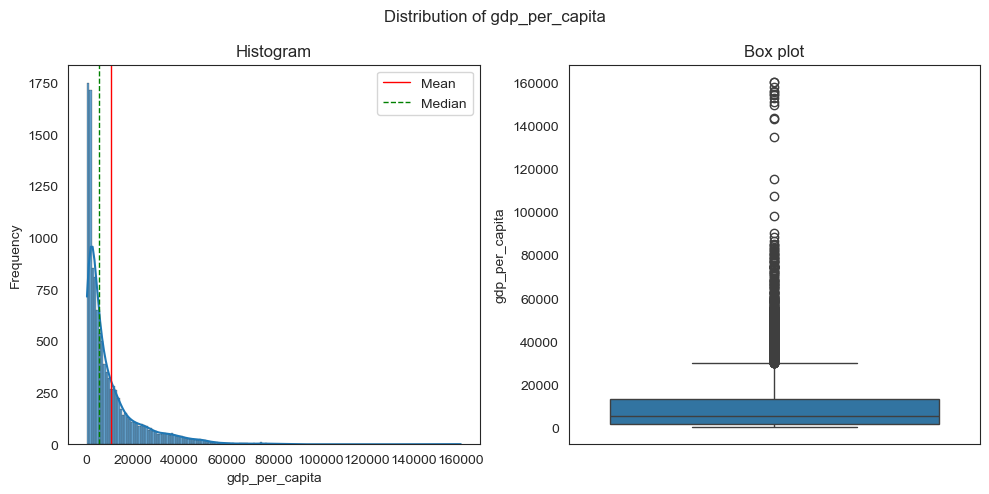


--- Summary stats for life_exp ---
Mean: 62.73
Median: 65.61
Std Dev: 12.54
Skewness: -0.55
Kurtosis: -0.57
Outliers: 8 (0.07%)


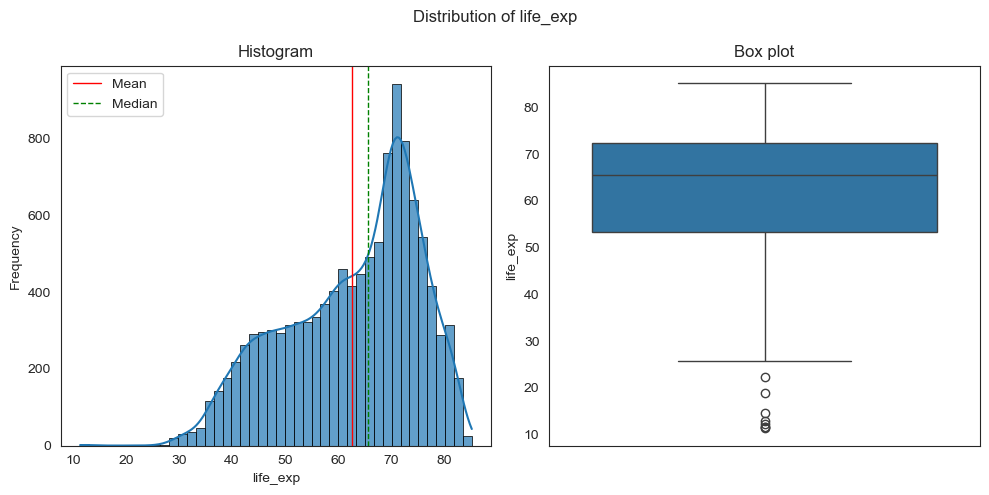

In [15]:
numeric_cols = ['year', 'mortality_per_1000', 'gdp_per_capita', 'life_exp']

for col in numeric_cols:
    univariate_analysis(df, col)


--- Summary stats for log_mortality_per_1000 ---
Mean: 2.33
Median: 2.29
Std Dev: 0.52
Skewness: -0.19
Kurtosis: 1.01
Outliers: 164 (1.42%)


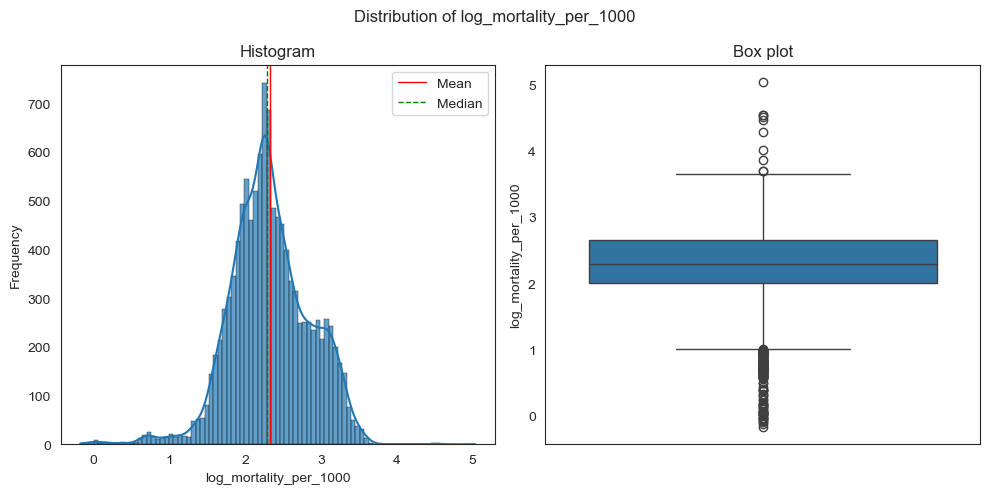


--- Summary stats for log_population ---
Mean: 15.70
Median: 15.73
Std Dev: 1.78
Skewness: -0.07
Kurtosis: 0.54
Outliers: 367 (3.18%)


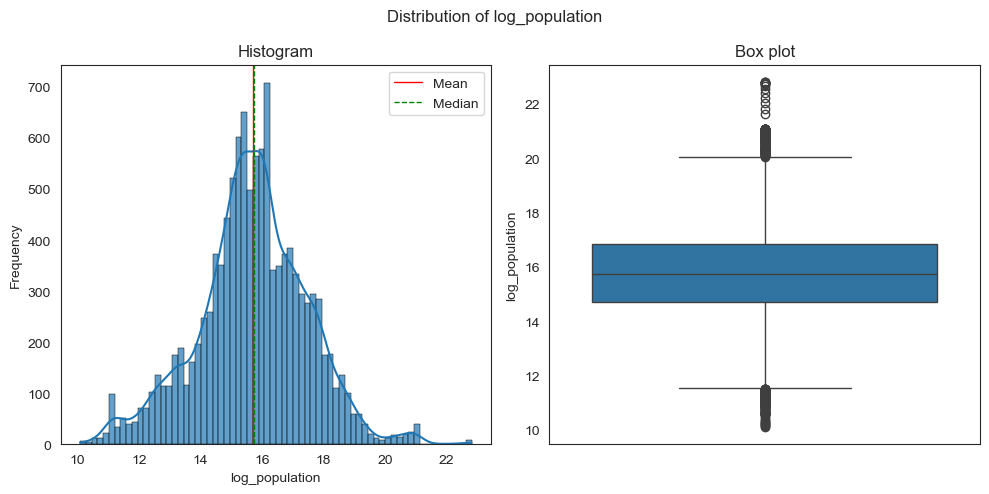


--- Summary stats for log_gdp_per_capita ---
Mean: 8.59
Median: 8.59
Std Dev: 1.18
Skewness: 0.11
Kurtosis: -0.91
Outliers: 0 (0.00%)


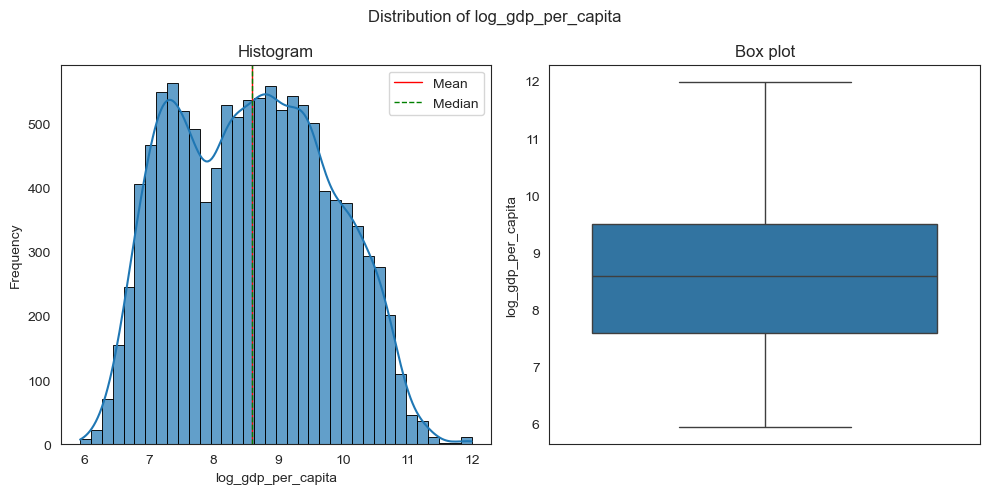

In [16]:
for col in ['mortality_per_1000', 'population', 'gdp_per_capita']:
    log_col = 'log_' + col
    df[log_col] = np.log(df[col])

    univariate_analysis(df, log_col)

## Global Mortality Rate

In [17]:
# Plotting choropleth map for Mortality rate
metric = 'mortality_per_1000'

fig = px.choropleth(df,
              locations = 'code',
              color = metric,
              hover_name = 'entity',
              hover_data = {'year' : True,
                            'mortality_per_1000' : ':.0f',
                            'gdp_per_capita' : ':.0f',
                            'life_exp' : ':.0f'},
              animation_frame = 'year',
              color_continuous_scale= 'Reds')

fig.update_geos(
    projection_type = 'natural earth',
    showcoastlines = True,
    landcolor = "rgb(240, 240, 240)",
    showframe = False
)

fig.update_layout(
    width = 1200,
    height = 700,
    margin = dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar = dict(title = 'Mortality (per 1000)',
                              title_side = 'right',
                              x = 0.5,
                              xanchor = 'center',
                              y = -0.1,
                              len = 0.5,
                              orientation = 'h',
                              thickness = 12),
    sliders = [{'pad' : {'t':30},
               'len': 0.8,
               'x':0.1,
               'y':-0.05,
               'currentvalue':{'font':{'size':18},
                               'prefix':'Year: ',
                               'visible' : True,
                               'xanchor':'center'}}],
     updatemenus=[{
        "buttons": [
            {
                "args": [None, {"frame": {"duration": 500, "redraw": True},
                                "fromcurrent": True}],
                "label": "Play",
                "method": "animate"
            },
            {
                "args": [[None], {"frame": {"duration": 0, "redraw": True},
                                  "mode": "immediate"}],
                "label": "Pause",
                "method": "animate"
            }
        ],
        "direction": "left",
        "pad": {"r": 10, "t": 70},
        "showactive": False,
        "x": 0.1,
        "y": 0
    }],
   title={
        "text": "Global Mortality Rate (1950 - 2022)",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 22}
    }
)

fig.show()


### Extreme Mortality and Life Expectancy Observations
**Historically**, the most extreme observations show a clear convergence of very high mortality rates and very low life expectancy, concentrated in a small number of country-year periods driven by systemic disruption.

The most severe cases, Cambodia (1975–1978) and Rwanda (1994), reflect periods of genocide and state collapse, where mortality spikes coincide with life expectancy dropping to near-minimal levels (~11–12 years).

A second group, including the Central African Republic (CAR), Burundi, Bangladesh, and early-period South Korea, reflects sustained instability, conflict exposure, or historically low baseline development. Within this group, the Central African Republic is particularly notable as it recorded high mortality values in recent years (2009 and 2022). The 2009 period reflects a fragile post-conflict setting with continued armed group activity and weak state control, resulting in persistently elevated mortality. By 2022, mortality remains high under conditions of ongoing civil war, fragmented territorial control, and repeated cycles of violence and displacement.

In [18]:
# Lowest mortality rate historically
df.sort_values(by = 'mortality_per_1000', ascending = False).head(10)

,entity,code,year,deaths,population,gdp_per_capita,life_exp,mortality_rate,mortality_per_1000,log_mortality_per_1000,log_population,log_gdp_per_capita
8884,Rwanda,RWA,1994,1045769,6792358,707.29710,12.158,0.153963,153.962586,5.036710,15.731309,6.561451
1545,Cambodia,KHM,1978,489494,5211654,1291.00000,11.573,0.093923,93.922966,4.542475,15.466408,7.163172
1544,Cambodia,KHM,1977,527082,5668561,1143.00000,11.295,0.092983,92.983387,4.532421,15.550446,7.041412
1543,Cambodia,KHM,1976,555801,6134989,1025.00000,11.632,0.090595,90.595272,4.506402,15.629519,6.932448
1542,Cambodia,KHM,1975,569757,6581373,925.00000,12.784,0.086571,86.571146,4.460967,15.699754,6.829794
1868,Central African Republic,CAF,2009,328277,4529051,898.70050,14.665,0.072483,72.482513,4.283345,15.326023,6.800950
1881,Central African Republic,CAF,2022,281036,5098038,596.39300,18.818,0.055126,55.126305,4.009627,15.444366,6.390900
9677,South Korea,KOR,1950,931034,19757319,998.08875,22.226,0.047123,47.123499,3.852772,16.799035,6.905842
1466,Burundi,BDI,1972,145990,3617134,866.00000,25.777,0.040361,40.360683,3.697856,15.101193,6.763885
693,Bangladesh,BGD,1971,2802344,70276757,934.00000,26.522,0.039876,39.875830,3.685770,18.067952,6.839476


In [19]:
# Lowest life expectancies historically
df.sort_values(by = 'life_exp', ascending = True).head(10)

,entity,code,year,deaths,population,gdp_per_capita,life_exp,mortality_rate,mortality_per_1000,log_mortality_per_1000,log_population,log_gdp_per_capita
1544,Cambodia,KHM,1977,527082,5668561,1143.00000,11.295,0.092983,92.983387,4.532421,15.550446,7.041412
1545,Cambodia,KHM,1978,489494,5211654,1291.00000,11.573,0.093923,93.922966,4.542475,15.466408,7.163172
1543,Cambodia,KHM,1976,555801,6134989,1025.00000,11.632,0.090595,90.595272,4.506402,15.629519,6.932448
8884,Rwanda,RWA,1994,1045769,6792358,707.29710,12.158,0.153963,153.962586,5.036710,15.731309,6.561451
1542,Cambodia,KHM,1975,569757,6581373,925.00000,12.784,0.086571,86.571146,4.460967,15.699754,6.829794
1868,Central African Republic,CAF,2009,328277,4529051,898.70050,14.665,0.072483,72.482513,4.283345,15.326023,6.800950
1881,Central African Republic,CAF,2022,281036,5098038,596.39300,18.818,0.055126,55.126305,4.009627,15.444366,6.390900
9677,South Korea,KOR,1950,931034,19757319,998.08875,22.226,0.047123,47.123499,3.852772,16.799035,6.905842
1466,Burundi,BDI,1972,145990,3617134,866.00000,25.777,0.040361,40.360683,3.697856,15.101193,6.763885
693,Bangladesh,BGD,1971,2802344,70276757,934.00000,26.522,0.039876,39.875830,3.685770,18.067952,6.839476


#### Recent Mortality Burden
The distribution of 10-year median mortality rates (2012 - 2022), shows both the level and stability of mortality across countries.

At the lower end, countries such as Qatar, United Arab Emirates, Kuwait, Bahrain, Oman, and Saudi Arabia exhibit very low median mortality rates with narrow IQRs. This indicates not only low mortality burden but also high temporal stability, with little year-to-year fluctuation. Similar patterns are observed in Jordan, Palestine, Singapore, and Honduras, though at slightly higher median levels. Overall, this group represents structurally stable, low-mortality environments.

At the higher end, countries such as Bulgaria, Latvia, Lithuania, Serbia, Ukraine, Romania, Croatia, and Hungary display consistently elevated median mortality rates. Their IQRs are generally modest, suggesting that high mortality is persistent rather than driven by short-term shocks. This points to underlying structural or demographic factors maintaining higher baseline mortality levels. Chad occupies a similar high-mortality position but with a wider IQR, indicating greater variability over time.  

The most notable case is the **Central African Republic**, which combines a high median mortality rate with an exceptionally large IQR. This reflects substantial instability, where periods of relatively lower mortality are interspersed with severe spikes, consistent with recurring crises or systemic disruptions.

In [20]:
recent_df = df[df['year'] >= (df['year'].max() - 10)]

avg_mortality_recent = recent_df.groupby('entity')['mortality_per_1000'].agg(
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3 = lambda x: x.quantile(0.75)
    ).reset_index()

In [21]:
avg_mortality_recent['iqr'] = avg_mortality_recent['q3'] - avg_mortality_recent['q1']

avg_mortality_recent.head()

,entity,median,q1,q3,iqr
0,Afghanistan,7.510522,7.293345,7.580997,0.287652
1,Albania,7.374118,7.240134,8.090936,0.850802
2,Algeria,4.654179,4.645550,4.674099,0.028548
3,Angola,8.191908,7.664467,8.994224,1.329757
4,Argentina,7.718922,7.629540,8.157483,0.527943


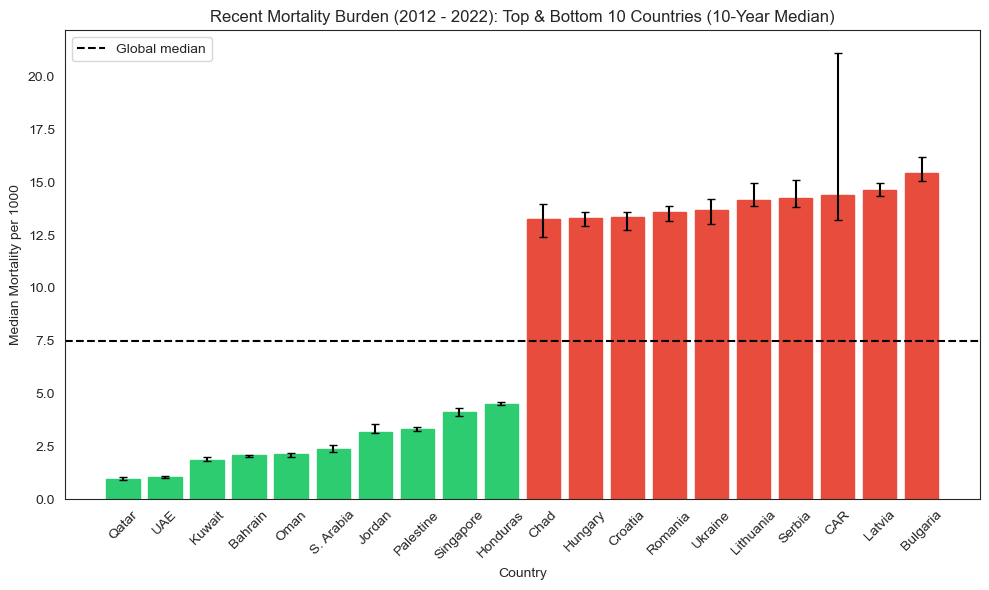

In [22]:
top_10 = avg_mortality_recent.sort_values('median', ascending=False).head(10)
bottom_10 = avg_mortality_recent.sort_values('median', ascending=True).head(10)

combined = pd.concat([bottom_10, top_10])
combined = combined.sort_values('median', ascending=True)

global_median = avg_mortality_recent['median'].median()

plt.figure(figsize=(10,6))

combined['color'] = combined['median'].apply(
    lambda x: "#2ECC71" if x < global_median else "#E74C3C"
)

combined['upper'] = combined['q3'] - combined['median']
combined['lower'] = combined['median'] - combined['q1']

sns.barplot(data = combined.replace({'United Arab Emirates':'UAE', 'Central African Republic': 'CAR', 'Saudi Arabia': 'S. Arabia'}), 
            x = 'entity', y = 'median')
plt.errorbar(x = range(len(combined)), y = combined['median'], yerr = [combined['lower'], combined['upper']],
             fmt = 'none', c = 'black', capsize = 3)

for i, bar in enumerate(plt.gca().patches):
    bar.set_color(combined['color'].iloc[i])

plt.axhline(global_median, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Global median')
plt.xticks(rotation = 45)
plt.xlabel('Country')
plt.ylabel('Median Mortality per 1000')
plt.title(f"Recent Mortality Burden ({recent_df['year'].min()} - {recent_df['year'].max()}): Top & Bottom 10 Countries (10-Year Median)")
plt.legend()

plt.tight_layout()
plt.show()

### COVID-19 and Global Mortality Rate

Global mortality rates declined steadily from approximately 19.5 deaths per 1000 population in 1950 to about 7.5 deaths per 1000 immediately before the COVID-19 pandemic, reflecting major long-term improvements in healthcare, sanitation, nutrition, and overall living conditions.

However, this downward trajectory was temporarily disrupted during the COVID-19 period (2020–2022). The global mortality rate increased from 7.50 deaths per 1000 during the pre-COVID period (2015–2019) to 8.20 deaths per 1000 during the pandemic years, representing an absolute increase of 0.70 deaths per 1000 and a relative increase of approximately 9.35%.

`Note:` these estimates reflect all-cause mortality rather than confirmed COVID-19 deaths alone, meaning the observed increase likely captures both direct pandemic mortality and indirect effects such as healthcare disruption and excess deaths.

In [23]:
pre_covid = df[(df['year'] >= 2015) & (df['year'] <= 2019)]
covid = df[(df['year'] >= 2020) & (df['year'] <= 2022)]

def global_mortality(x):
    return(x['deaths'].sum() / x['population'].sum()) * 1000

pre_rate = global_mortality(pre_covid)
covid_rate = global_mortality(covid)

print(f'Pre-COVID (2015–2019): {pre_rate:.2f} deaths per 1000')
print("COVID (2020–2022):", f'{covid_rate:.2f} deaths per 1000')
print("Change (Pre-COVID - COVID):", f'{covid_rate - pre_rate:.2f}')
print("Percent change:", f'{(covid_rate - pre_rate) / pre_rate * 100:.2f}%')

Pre-COVID (2015–2019): 7.50 deaths per 1000
COVID (2020–2022): 8.20 deaths per 1000
Change (Pre-COVID - COVID): 0.70
Percent change: 9.35%


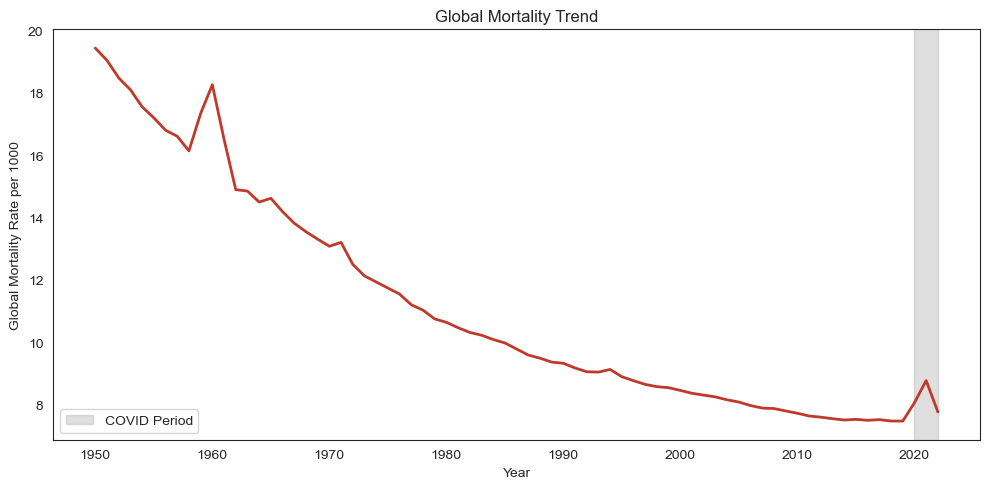

In [24]:
global_trend = (df.groupby('year')
                .apply(lambda x: (x['deaths'].sum() / x['population'].sum()) * 1000)
                .reset_index(name = 'mortality_per_1000'))

# Global Mortality Rate Plot
plt.figure(figsize = (10, 5))

sns.lineplot(data = global_trend, 
             x = 'year', 
             y = 'mortality_per_1000',
             linewidth = 2,
             color = '#C0392B')

plt.axvspan(2020, 2022,
            color = 'grey',
            alpha = 0.25,
            label = 'COVID Period')

# Labels
plt.xlabel('Year')
plt.ylabel('Global Mortality Rate per 1000')
plt.title('Global Mortality Trend')

plt.legend()

plt.tight_layout()
plt.show()

### COVID-19 and Country-level Mortality Rate

In [25]:
covid = (df[(df['year'] >= 2020) & (df['year'] <= 2022)]
         .groupby('entity')['mortality_per_1000'].mean()
         .reset_index(name = 'covid_mr')
         )

top_5 = covid.sort_values(by = 'covid_mr', ascending = False).head()

print(top_5)

                       entity   covid_mr
26   Central African Republic  29.758245
19                   Bulgaria  18.805710
131                    Serbia  17.442780
82                     Latvia  16.344222
87                  Lithuania  16.056466


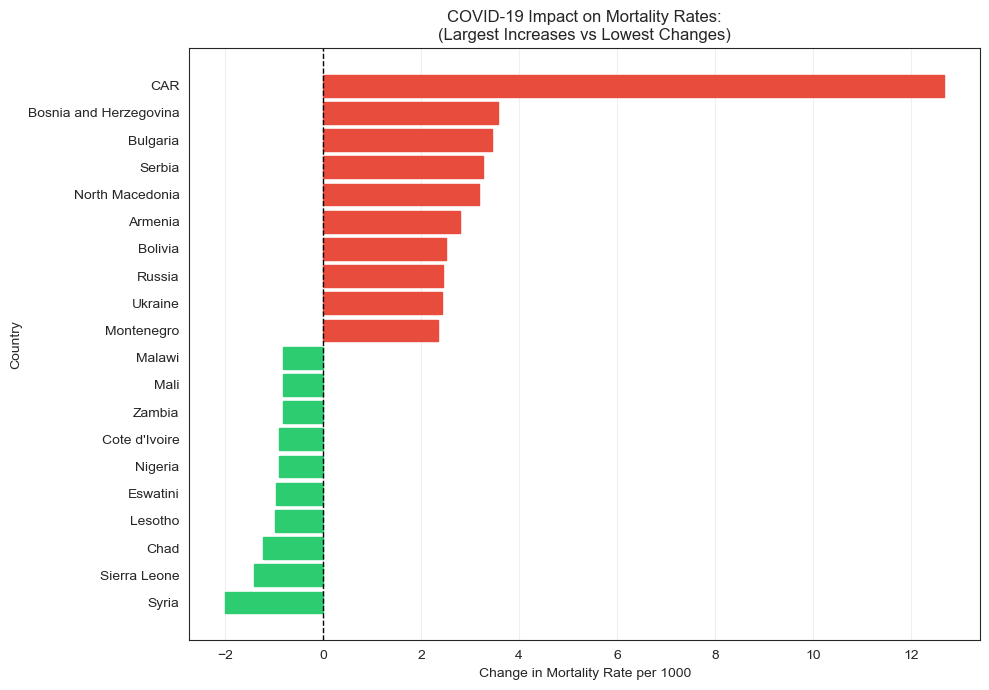

In [26]:
pre_covid = (df[(df['year'] >= 2015) & (df['year'] <= 2019)]
         .groupby('entity')['mortality_per_1000'].mean()
         .reset_index(name = 'pre_covid_mr')
         )

covid_change = pre_covid.merge(covid, on = 'entity')
covid_change['absolute_change'] =  covid_change['covid_mr'] - covid_change['pre_covid_mr']
covid_change['percent_change'] = covid_change['absolute_change'] / covid_change['pre_covid_mr'] * 100

# Top worsening countries
worst_10 = covid_change.sort_values(
    'absolute_change',
    ascending=False
).head(10)

# Lowest change / improvement countries
best_10 = covid_change.sort_values(
    'absolute_change',
    ascending=True
).head(10)

# Combine
combined = pd.concat([best_10, worst_10])

# Sort for plotting
combined = combined.sort_values('absolute_change')

# Colors
combined['color'] = combined['absolute_change'].apply(
    lambda x: '#2ECC71' if x < 0 else '#E74C3C'
)

# Optional short labels
combined['entity'] = combined['entity'].replace({
    'United Arab Emirates': 'UAE',
    'Central African Republic': 'CAR'
})

# Plot
plt.figure(figsize=(10, 7))

bars = plt.barh(
    combined['entity'],
    combined['absolute_change']
)

# Apply colors
for bar, color in zip(bars, combined['color']):
    bar.set_color(color)

# Reference line
plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.xlabel('Change in Mortality Rate per 1000')
plt.ylabel('Country')

plt.title(
    'COVID-19 Impact on Mortality Rates:\n'
    '(Largest Increases vs Lowest Changes)'
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Time Series Analysis

In [27]:
# Country with lowest mortality rate (historically)
best_country = df.groupby('entity')['mortality_per_1000'].mean().idxmin()
best_df = df[df['entity'] == best_country].sort_values('year')

# Average of global metrics (historically)
def compute_global_metrics(x):
    pop = x['population'].sum()
    return pd.Series({
        'mortality_per_1000': x['deaths'].sum() / pop * 1000,
        'gdp_per_capita' : (x['gdp_per_capita'] * x['population']).sum() / pop,
        'life_exp' : (x['life_exp'] * x['population']).sum() / pop
    })

global_df = df.groupby('year').apply(compute_global_metrics).reset_index()

In [28]:
def time_series_analysis(df, entity, metrics, labels, best_df, best_country, global_df):
    entity_df = df[df['entity'] == entity].sort_values('year').copy()

    if len(entity_df) == 0:
        print(f'No data for {entity}')
        return
    
    print(f"Time series analysis: {entity}")
    print(f"{'-'*60}")

    for metric in metrics:
        entity_df[f'{metric}_yoy_change'] = entity_df[metric].pct_change() * 100
      
        fig, axes = plt.subplots(2, 1, figsize=(10, 10), 
                                 sharex=True,
                                 gridspec_kw= {'height_ratios' : [1.5,1]})

        # Plot for selected country
        sns.lineplot(
            data=entity_df,
            x='year',
            y=metric,
            marker='o',
            linewidth=2,
            ax=axes[0],
            color="#014fe0",
            label = entity
        )

        # Best country
        sns.lineplot(
            data = best_df,
            x = 'year',
            y = metric,
            linestyle = '--',
            color = '#2ECC71',
            label = f'Best: {best_country}',
            ax = axes[0]
        )

        # Global average
        sns.lineplot(
            data = global_df,
            x = 'year',
            y = metric,
            linestyle = ':',
            color = 'black',
            label = 'Global Avg',
            ax = axes[0]
        )

        axes[0].set_ylabel(labels[metric])
        axes[0].set_title(f'{labels[metric]} Trend: {entity} vs Best vs Global')
        axes[0].grid(True, alpha=0.3)
        
        # Trend line
        show_trend = False
        if show_trend:
            valid = entity_df[['year', metric]].dropna()
            if len(valid) > 1:
                z = np.polyfit(valid['year'], valid[metric], 1)
                p = np.poly1d(z)

                axes[0].plot(
                    valid['year'],
                    p(valid['year']),
                    linestyle='--',
                    color='grey',
                    alpha=0.5,
                    linewidth = 1,
                    label=f'Trend: {z[0]:.2f}/year'
                )
        axes[0].legend()

        # YOY change
        axes[1].bar(
            entity_df['year'],
            entity_df[f'{metric}_yoy_change'],
            color='orange',
            alpha=0.6
        )

        axes[1].axhline(0, color='black', linewidth=1)  # baseline
        axes[1].set_ylabel('YoY % change')
        axes[1].set_xlabel('Year')
        axes[1].set_title(f'{labels[metric]} Year-on-Year Change in {entity}')
        axes[1].grid(True, alpha=0.3)

        
        # Print Stats
        print(f'\n{metric}')
        print(f"Starting value ({entity_df['year'].min()}): {entity_df[metric].iloc[0]:.2f}")
        print(f"Ending value ({entity_df['year'].max()}): {entity_df[metric].iloc[-1]:.2f}")
        print(f"Total change: {entity_df[metric].iloc[-1] - entity_df[metric].iloc[0]:.2f}")
        print(f"Avg YoY change: {entity_df[f'{metric}_yoy_change'].mean():.2f}%")

        plt.tight_layout()
        plt.show()

Time series analysis: Nigeria
------------------------------------------------------------

mortality_per_1000
Starting value (1950): 27.51
Ending value (2022): 11.95
Total change: -15.56
Avg YoY change: -1.15%


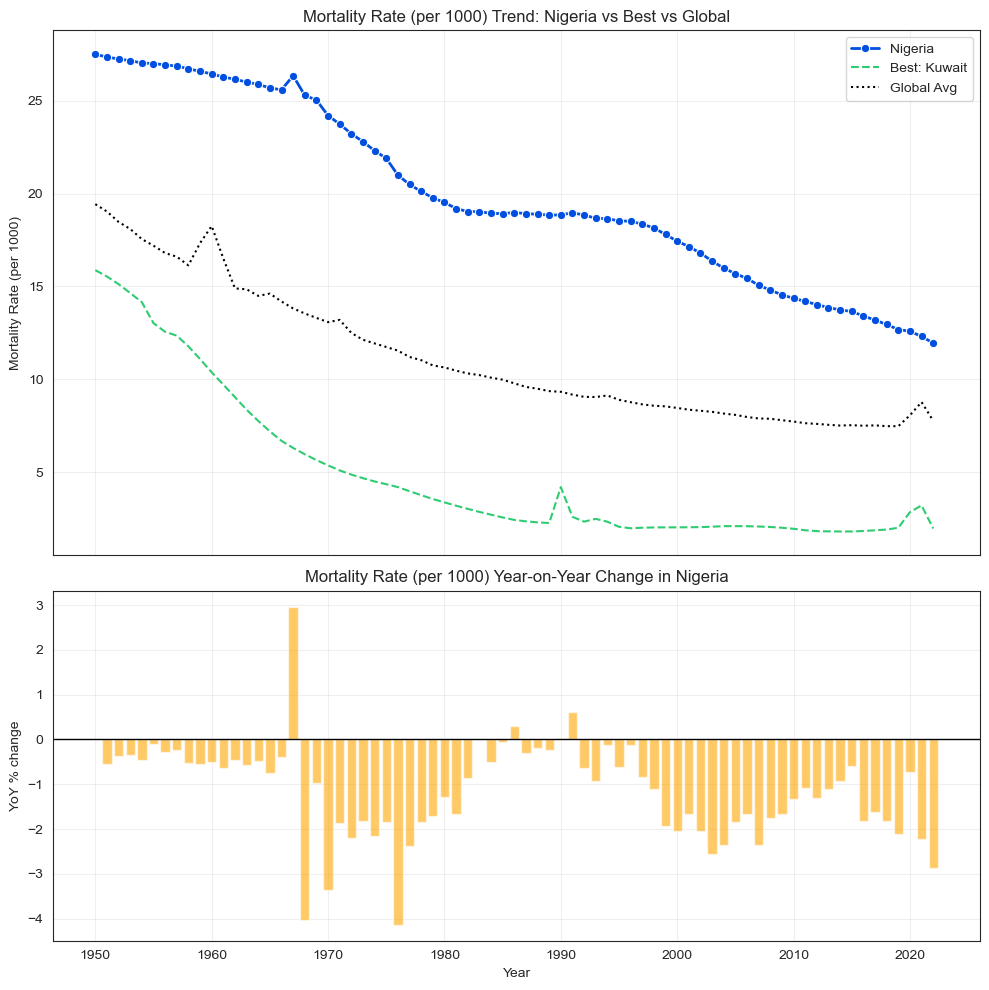


gdp_per_capita
Starting value (1950): 1200.00
Ending value (2022): 5070.49
Total change: 3870.49
Avg YoY change: 2.23%


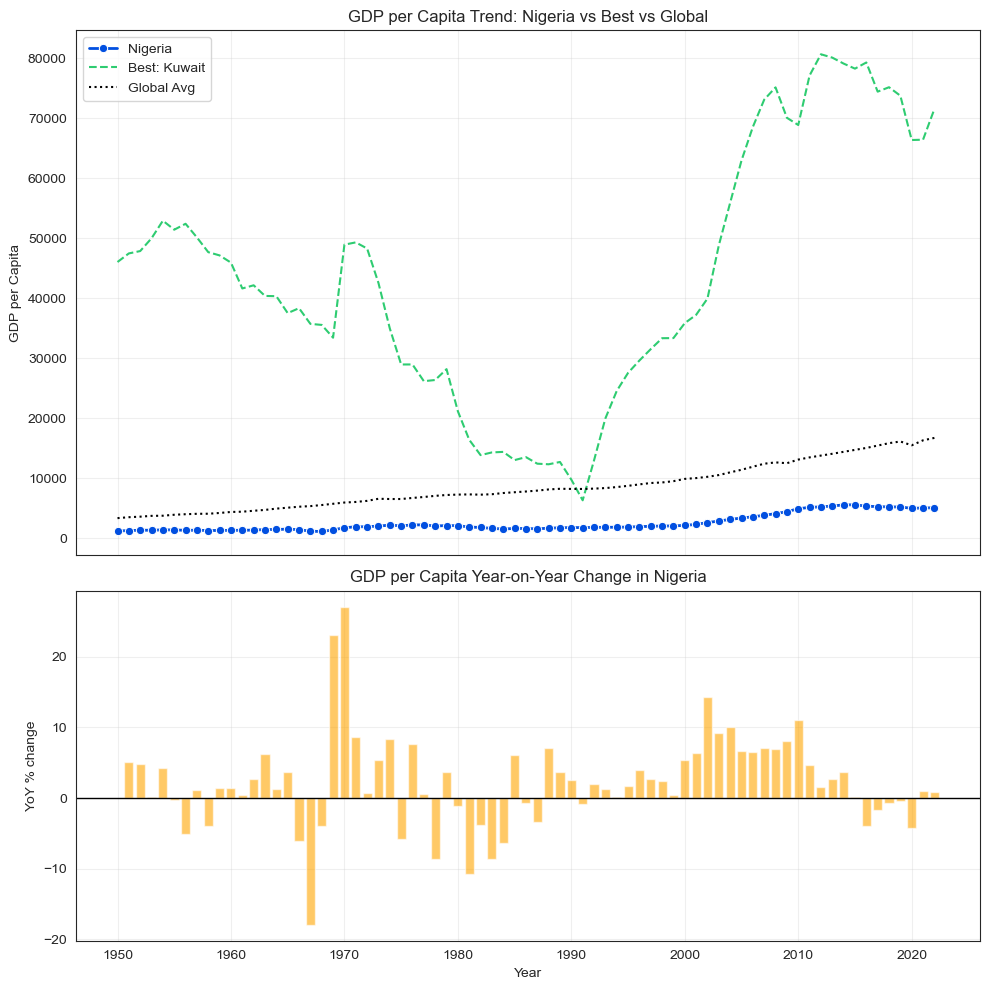

In [29]:
time_series_analysis(df, 'Nigeria', ['mortality_per_1000', 'gdp_per_capita'], {'mortality_per_1000':'Mortality Rate (per 1000)', 'gdp_per_capita':'GDP per Capita'}, best_df, best_country, global_df)

Time series analysis: United States
------------------------------------------------------------

mortality_per_1000
Starting value (1950): 9.60
Ending value (2022): 9.33
Total change: -0.26
Avg YoY change: 0.00%


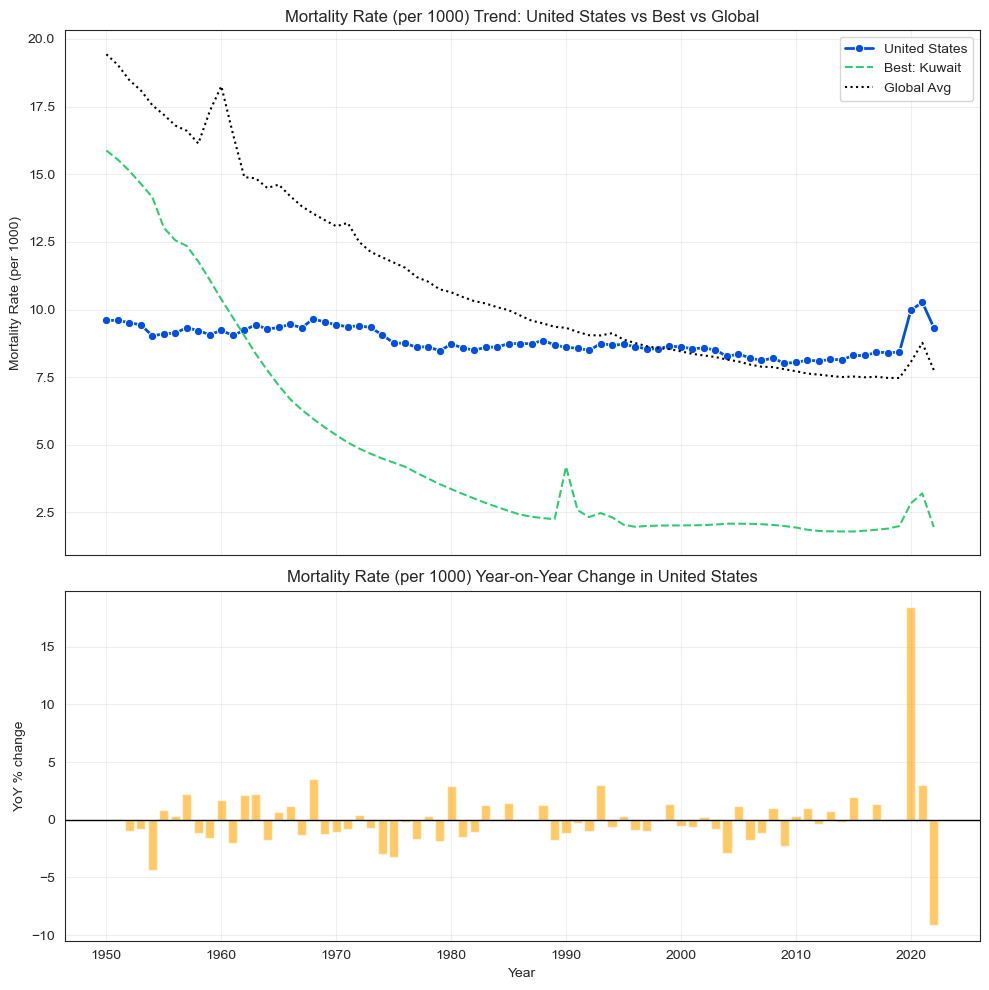


gdp_per_capita
Starting value (1950): 15240.00
Ending value (2022): 58487.46
Total change: 43247.46
Avg YoY change: 1.91%


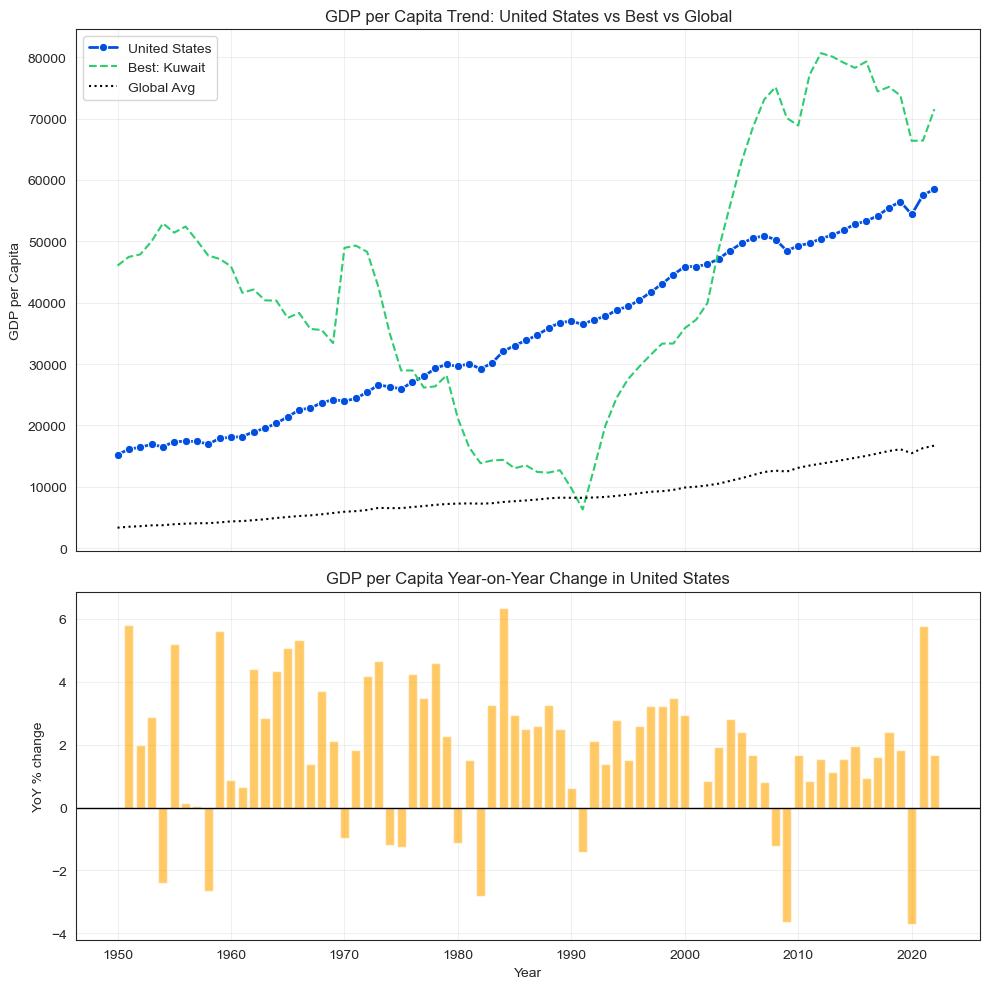

In [30]:
time_series_analysis(df, 'United States', ['mortality_per_1000', 'gdp_per_capita'], {'mortality_per_1000':'Mortality Rate (per 1000)', 'gdp_per_capita':'GDP per Capita'}, best_df, best_country, global_df)

Time series analysis: Qatar
------------------------------------------------------------

mortality_per_1000
Starting value (1950): 16.58
Ending value (2022): 0.93
Total change: -15.65
Avg YoY change: -3.84%


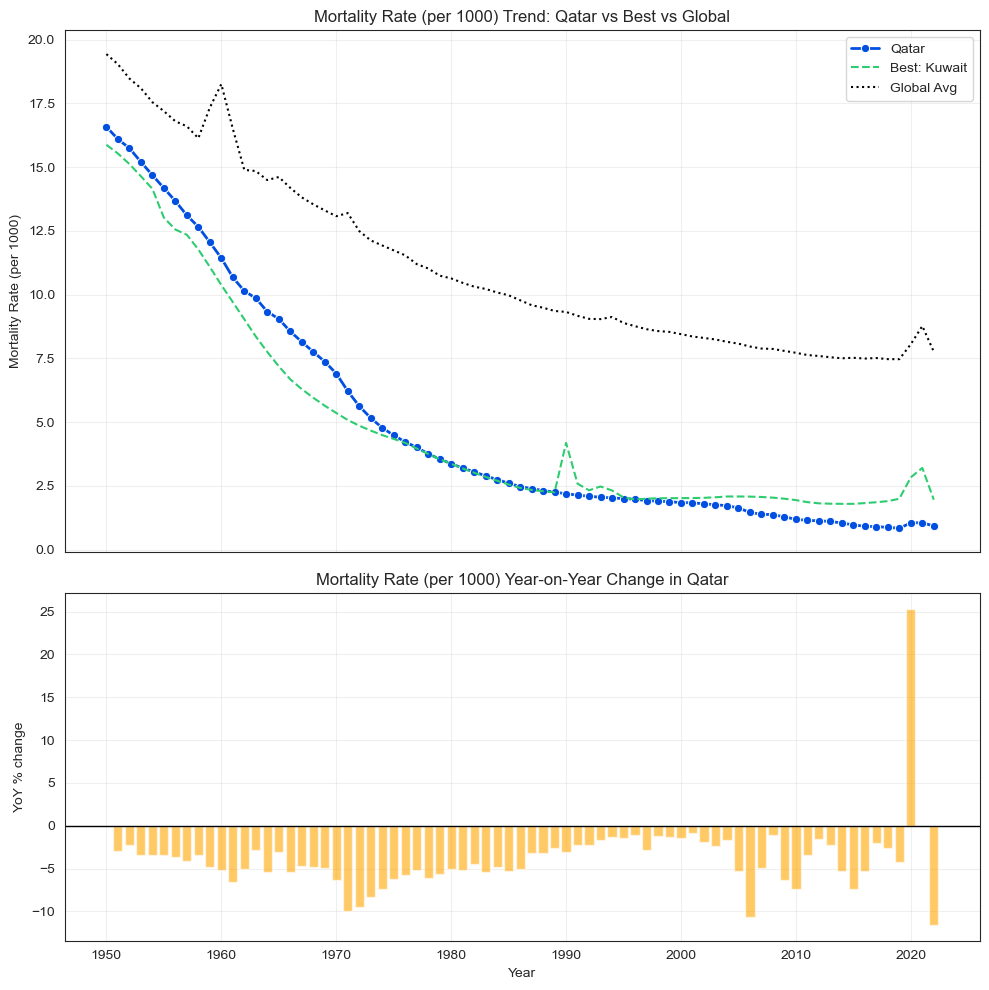


gdp_per_capita
Starting value (1950): 48436.00
Ending value (2022): 149171.11
Total change: 100735.11
Avg YoY change: 2.17%


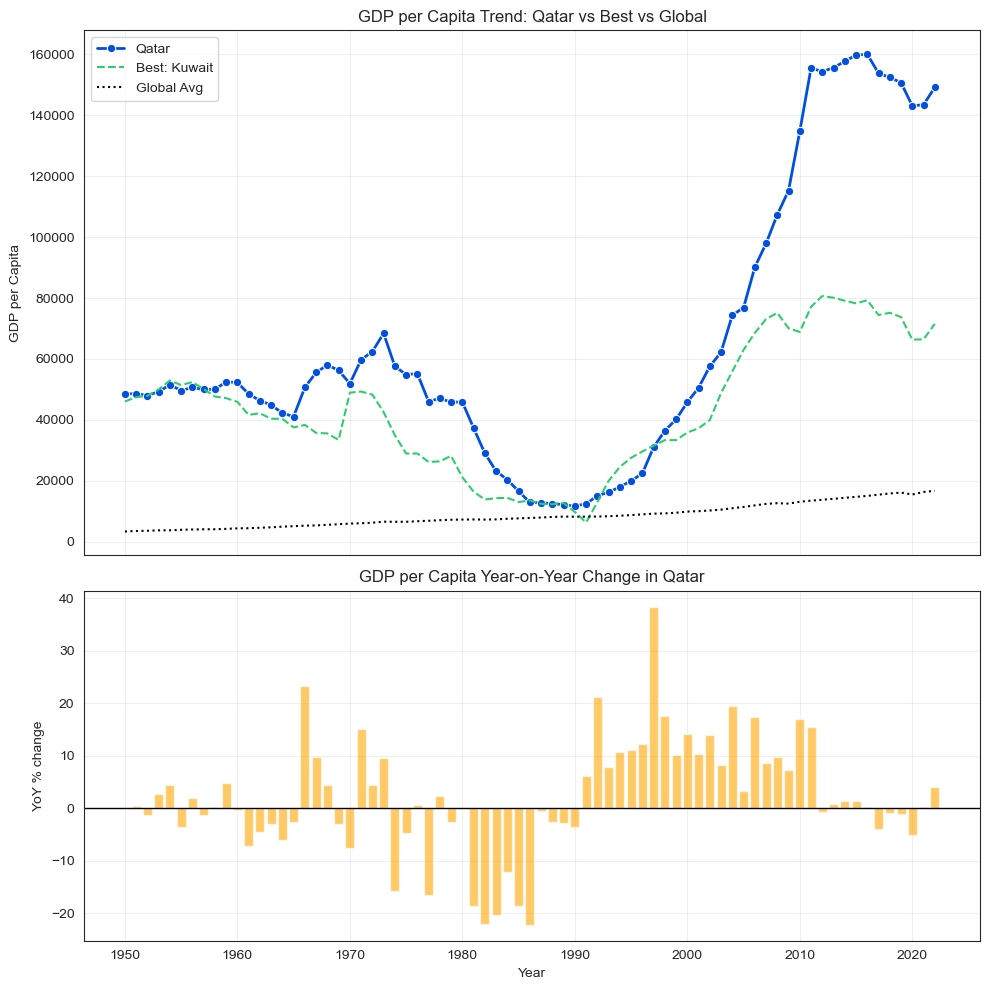

In [31]:
time_series_analysis(df, 'Qatar', ['mortality_per_1000', 'gdp_per_capita'], {'mortality_per_1000':'Mortality Rate (per 1000)', 'gdp_per_capita' : 'GDP per Capita'}, best_df, best_country, global_df)

## Forecasting Global Mortality Trends to 2050

To establish baseline forecasting approaches, both `Linear regression` and `Polynomial regression` models were initially applied to the historical global mortality trend. These models produced substantially different future trajectories.

The linear regression model projected a continuous and nearly constant decline in mortality rates through 2050, while the polynomial regression model produced an upward reversal following the COVID-19 mortality spike. 
In particular, the polynomial model appeared highly influenced by the temporary increase in mortality during the COVID-19 period, resulting in unstable long-term projections. In contrast, the linear model likely oversimplified the mortality trend by assuming a constant rate of decline indefinitely.

Because of these limitations, a more appropriate time-series forecasting approach was subsequently adopted using `Exponential Smoothing (ETS)`. The ETS forecast projects that global mortality rates may continue to decline gradually through 2050, although at a slower pace than observed during earlier decades. This slowing decline is demographically plausible, as mortality improvements typically become less dramatic at lower mortality levels and may eventually stabilize due to population aging and chronic disease burden.

However, these forecasts should be interpreted cautiously. The model assumes that historical mortality dynamics will continue into the future under relatively stable global conditions. Unexpected events such as pandemics, wars, climate-related crises, healthcare disruptions, or major demographic shifts could substantially alter future mortality trajectories.

In [32]:
X = global_trend[['year']]
y = global_trend['mortality_per_1000']

model = LinearRegression()

model.fit(X, y)

forecast_df = pd.DataFrame({'year':range(2023, 2051)})

forecast_df['forecast_mr'] = model.predict(forecast_df[['year']])

forecast_df.head()


,year,forecast_mr
0,2023,5.313869
1,2024,5.155931
2,2025,4.997993
3,2026,4.840055
4,2027,4.682117


In [33]:
poly_model = make_pipeline(PolynomialFeatures(degree = 2),
                          LinearRegression())

poly_model.fit(X, y)

forecast_df['poly_mr'] = poly_model.predict(forecast_df[['year']])

forecast_df.head()

,year,forecast_mr,poly_mr
0,2023,5.313869,8.031332
1,2024,5.155931,8.093729
2,2025,4.997993,8.162002
3,2026,4.840055,8.236150
4,2027,4.682117,8.316174


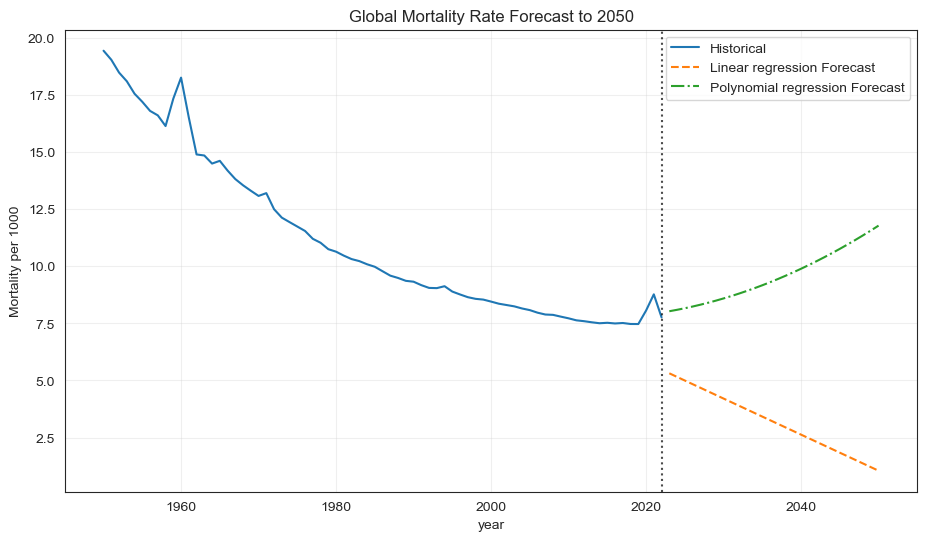

In [34]:
plt.figure(figsize = (11, 6))

# Historical
sns.lineplot(
    data=global_trend,
    x='year',
    y='mortality_per_1000',
    label='Historical'
)

# Linear regression Forecast
sns.lineplot(
    data=forecast_df,
    x='year',
    y='forecast_mr',
    linestyle='--',
    label='Linear regression Forecast'
)

# Linear regression Forecast
sns.lineplot(
    data=forecast_df,
    x='year',
    y='poly_mr',
    linestyle='-.',
    label='Polynomial regression Forecast'
)

plt.axvline(
    2022,
    color='black',
    linestyle=':',
    alpha=0.7
)

plt.title('Global Mortality Rate Forecast to 2050')

plt.ylabel('Mortality per 1000')

plt.grid(alpha=0.3)

plt.show()

In [35]:
df_ets = global_trend.set_index(pd.to_datetime(global_trend['year'], format = '%Y'))

model_ets = ExponentialSmoothing(df_ets['mortality_per_1000'], trend = 'add', damped_trend = True).fit()

forecast_ets = model_ets.forecast(28)

forecast_ets.head()

c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


2023-01-01    7.722676
2024-01-01    7.683525
2025-01-01    7.645637
2026-01-01    7.608970
2027-01-01    7.573486
Freq: YS-JAN, dtype: float64

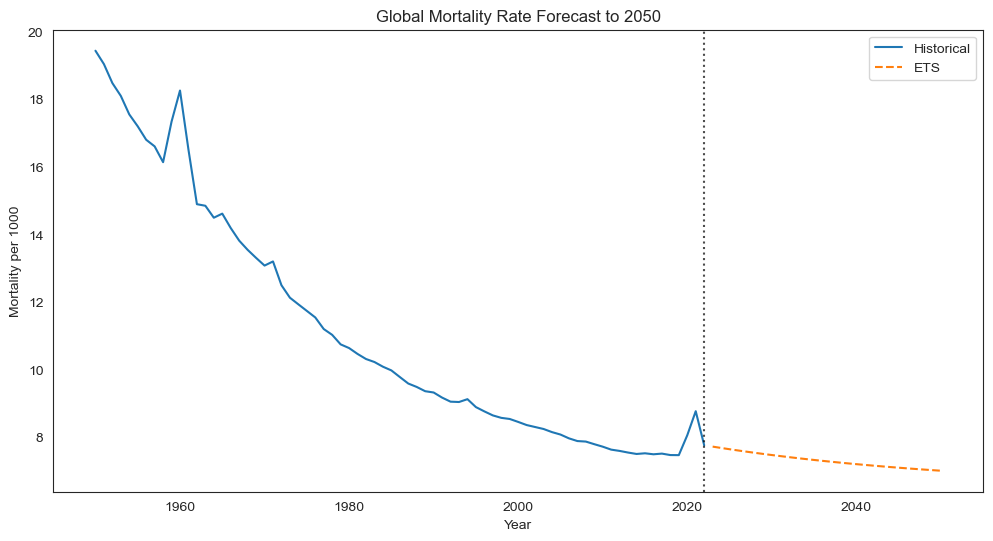

In [36]:
plt.figure(figsize = (12,6))
sns.lineplot(x = global_trend['year'], y = global_trend['mortality_per_1000'], label = 'Historical')
plt.plot(range(2023, 2051), forecast_ets, label = 'ETS', linestyle = '--')
plt.axvline(2022, linestyle = ':', color = 'black', alpha = 0.7)

plt.title('Global Mortality Rate Forecast to 2050')
plt.xlabel('Year')
plt.ylabel('Mortality per 1000')

plt.legend()
plt.show()

## Limitations

Several limitations should be considered when interpreting the findings from this analysis.

- First, the study relied on secondary historical mortality data aggregated at the country-year level. As a result, the analysis could not account for within-country heterogeneity, including regional, socioeconomic, healthcare access, or demographic differences that may substantially influence mortality patterns.

- Second, mortality rates were analyzed primarily using crude mortality measures (deaths per 1000 population). Crude mortality is strongly influenced by population age structure and demographic composition. Countries with older populations may exhibit higher mortality rates despite having more advanced healthcare systems and better overall health outcomes.

- Third, historical mortality estimates may be affected by inconsistencies in death registration systems, reporting quality, conflict-related underreporting, and differences in national data collection practices, particularly in earlier decades and low-resource settings.

- Fourth, several extreme mortality events identified in the analysis—such as genocide, armed conflict, famine, and pandemics—represent highly unusual historical shocks that can strongly influence trend estimation and forecasting models. While these events are epidemiologically important, they may distort long-term statistical projections.

- Fifth, the forecasting analysis assumed that historical mortality dynamics would continue into the future under relatively stable global conditions. Forecasting models such as linear regression, polynomial regression, and Exponential Smoothing cannot anticipate future structural disruptions, including pandemics, wars, economic crises, climate-related disasters, healthcare system collapse, or major demographic transitions.

- Additionally, the forecasting models did not explicitly incorporate important explanatory variables such as age distribution, fertility trends, migration, healthcare expenditure, disease burden, or technological advancement. Consequently, the forecasts should be interpreted as trend-based projections rather than causal predictions.

- Finally, the analysis was exploratory in nature and primarily focused on identifying large-scale global patterns and temporal trends rather than establishing causal relationships between mortality and socioeconomic indicators.